In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("Order_Delivery_Performance_Dataset (2).csv")

### Correlation Matrix across Shipping_Cost and Order_Value

In [4]:
correlation = df[['Shipping_Cost', 'Order_Value']].corr()

print("Correlation Matrix")
print(correlation)

Correlation Matrix
               Shipping_Cost  Order_Value
Shipping_Cost       1.000000    -0.007535
Order_Value        -0.007535     1.000000


### Correlation Matrix with Heatmap


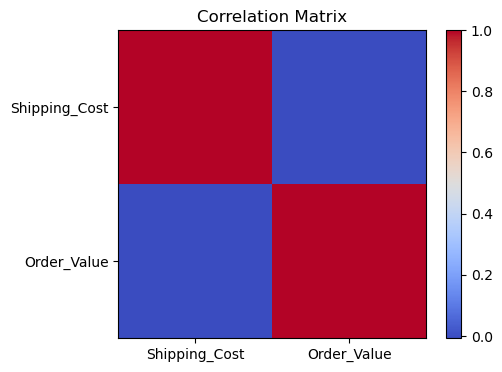

In [5]:
import matplotlib.pyplot as plt

corr = df[['Shipping_Cost','Order_Value']].corr()

plt.figure(figsize=(5,4))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

### Variance Analysis by Delivery_Status

In [7]:
delivery_variance = df.groupby("Delivery_Status").agg(
    Shipping_Cost_Variance=("Shipping_Cost","var"),
    Order_Value_Variance=("Order_Value","var")
)

print(delivery_variance)

                 Shipping_Cost_Variance  Order_Value_Variance
Delivery_Status                                              
Cancelled                  17773.333091          1.991321e+08
Delayed                    17492.206521          2.093444e+08
On Time                    16870.324602          2.064332e+08


### Variance Analysis by Region

In [8]:
region_variance = df.groupby("Region").agg(
    Shipping_Cost_Variance=("Shipping_Cost","var"),
    Order_Value_Variance=("Order_Value","var")
)

print(region_variance)

         Shipping_Cost_Variance  Order_Value_Variance
Region                                               
Central            17069.155963          2.041987e+08
East               16617.100826          2.061845e+08
North              17399.578620          2.076986e+08
South              17162.402881          2.033134e+08
West               17077.001108          2.099953e+08


### Variance Analysis by Product_Category

In [9]:
category_variance = df.groupby("Product_Category").agg(
    Shipping_Cost_Variance=("Shipping_Cost","var"),
    Order_Value_Variance=("Order_Value","var")
)

print(category_variance)

                  Shipping_Cost_Variance  Order_Value_Variance
Product_Category                                              
Beauty                      17124.432079          2.077848e+08
Electronics                 17256.220259          1.996937e+08
Fashion                     17510.680745          2.095116e+08
Grocery                     17229.446545          2.060519e+08
Home                        16395.019114          2.090845e+08
Sports                      16788.822490          2.054134e+08


### Statistical Validation (Pearson Correlation Test)

In [10]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["Shipping_Cost"], df["Order_Value"])

print("Correlation Coefficient:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant relationship.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No statistically significant relationship.")

Correlation Coefficient: -0.007534511365112195
P-value: 0.4512290217440252
Fail to Reject the Null Hypothesis
No statistically significant relationship.


### Statistical Validation using One-Way ANOVA

In [11]:
from scipy.stats import f_oneway

groups = [
    group["Order_Value"].values
    for name, group in df.groupby("Delivery_Status")
]

f_stat, p_value = f_oneway(*groups)

print("F Statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Average Order Value differs across Delivery Status.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference among Delivery Status groups.")

F Statistic: 0.037011217127470276
P-value: 0.9636654577763664
Fail to Reject Null Hypothesis
No significant difference among Delivery Status groups.


### Interpretation
1. Correlation coefficient shows the strength and direction of the relationship.
2. P-value less than 0.05 indicates statistical significance.
3. Higher variance means greater spread in values.
4. ANOVA determines whether group means differ significantly.

### Limitations
1. Results depend on the quality of the dataset.
2. Missing values and outliers may influence the analysis.
3. Correlation does not imply causation.
4. ANOVA assumes normal distribution and equal variances.
5. Findings apply only to the available dataset.